In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
classification_df = pd.read_csv('updated_classification_results')
regression_df = pd.read_csv('updated_regression_results')

In [6]:
# Aggregate the dataframe to get the mean time across seeds for each K
df = classification_df.groupby(['K','alpha']).mean().reset_index()
print(df[['K','alpha','ifls_euclidean', 'gtg_euclidean', 'perm_euclidean']])

     K  alpha  ifls_euclidean  gtg_euclidean  perm_euclidean
0    5    0.1        6.625734       0.613647        0.248637
1    5    0.5        0.045758       0.055495        0.204173
2    5    1.0        0.024832       0.028872        0.203783
3    5    5.0        0.009377       0.021430        0.203726
4   10    0.1        5.167605       0.227104        0.158403
5   10    0.5        0.046098       0.047829        0.144494
6   10    1.0        0.016009       0.019662        0.144153
7   10    5.0        0.005004       0.015467        0.144202
8   15    0.1        4.437105       0.180369        0.138080
9   15    0.5        0.169397       0.036710        0.119125
10  15    1.0        0.012293       0.018046        0.118725
11  15    5.0        0.003259       0.012856        0.118724


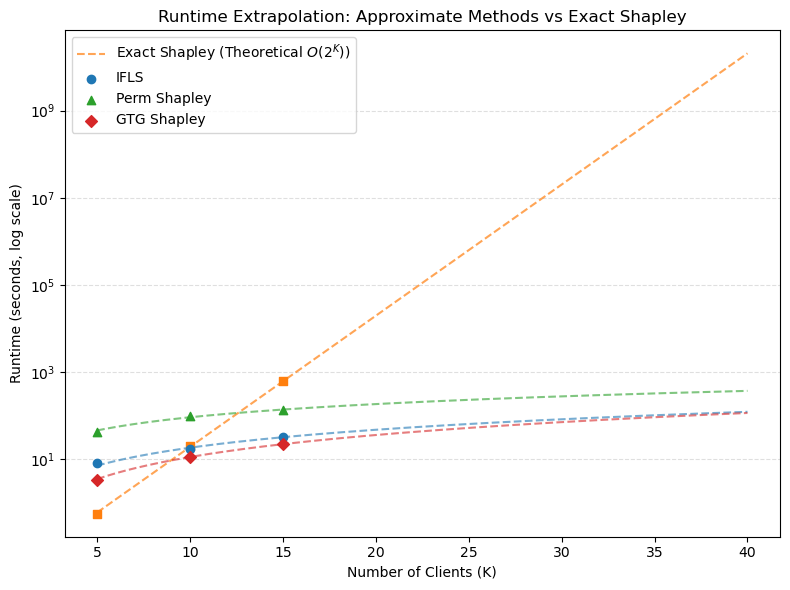

In [7]:
from scipy.optimize import curve_fit

def polynomial(x, a, b): 
    return a * np.power(x, b)

Ks = np.array([5, 10, 15])
Ks_extended = np.linspace(5, 40, 200)

fig, ax = plt.subplots(figsize=(8, 6))
df_time = classification_df.groupby('K').mean(numeric_only=True).reset_index()

# Scale theoretical O(2^K) curve to observed K=15 exact timing
t_15 = df_time[df_time['K'] == 15]['time_exact'].values[0]
scale = t_15 / (2 ** 15)
y_theoretical = scale * np.power(2, Ks_extended)

# Approximate methods — polynomial fit
approx_methods = [
    (df_time['time_ifls'], 'IFLS',         'tab:blue',   'o'),
    (df_time['time_perm'], 'Perm Shapley', 'tab:green',  '^'),
    (df_time['time_gtg'],  'GTG Shapley',  'tab:red',    'D'),
]

# Plot theoretical exact curve
ax.plot(Ks_extended, y_theoretical, color='tab:orange', 
        linestyle='--', alpha=0.7, label='Exact Shapley (Theoretical $O(2^K)$)')
ax.scatter(Ks, df_time['time_exact'].values, 
           color='tab:orange', marker='s', zorder=5)

# Plot approximate methods
for data, label, color, marker in approx_methods:
    y_vals = data.values
    popt, _ = curve_fit(polynomial, Ks, y_vals)
    y_extrapolated = polynomial(Ks_extended, *popt)
    ax.plot(Ks_extended, y_extrapolated, color=color, linestyle='--', alpha=0.6)
    ax.scatter(Ks, y_vals, color=color, marker=marker, label=f'{label}', zorder=5)


ax.set_yscale('log')
ax.set_xlabel('Number of Clients (K)')
ax.set_ylabel('Runtime (seconds, log scale)')
ax.set_title('Runtime Extrapolation: Approximate Methods vs Exact Shapley')
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

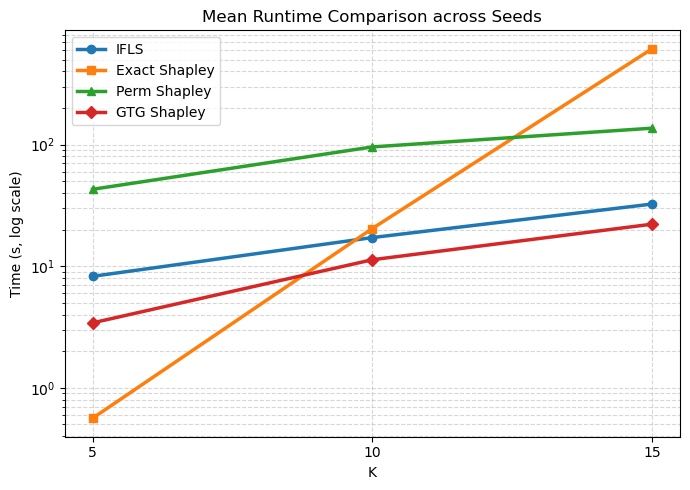

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
Ks = [5, 10, 15]

# Aggregate the dataframe to get the mean time across seeds for each K
df_time = classification_df.groupby('K').mean().reset_index()

methods = [
    (df_time['time_ifls'],  'IFLS',          'tab:blue',   'o'),
    (df_time['time_exact'], 'Exact Shapley', 'tab:orange', 's'),
    (df_time['time_perm'],  'Perm Shapley',  'tab:green',  '^'),
    (df_time['time_gtg'],   'GTG Shapley',   'tab:red',    'D'),
]

for data, label, color, marker in methods:
    # Ensure data is sorted by K to match the x-axis
    y_vals = data.values
    ax.plot(Ks, y_vals, color=color, linewidth=2.5, marker=marker, markersize=6, label=label)

ax.set_yscale('log')
ax.set_xlabel('K')
ax.set_ylabel('Time (s, log scale)')
ax.set_title('Mean Runtime Comparison across Seeds')
ax.set_xticks(Ks)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

In [25]:
print(df_time[['K','time_gtg', 'time_ifls', 'time_perm', 'time_exact']])

    K   time_gtg  time_ifls   time_perm  time_exact
0   5   3.418136   8.248874   42.859703    0.561733
1  10  11.295073  17.183120   95.608697   20.397153
2  15  22.147945  32.414623  136.331209  612.707313


In [20]:
N_SEEDS = 10

METHOD_STYLES = {
    'ifls': ('IFLS','tab:blue'),
    'perm': ('Perm Shapley', 'tab:green'),
    'gtg':  ('GTG Shapley',  'tab:red'),
}

def compute_stats(df, group_cols, metric_cols):
    """
    Returns mean and standard error grouped by group_cols.
    metric_cols: list of column names e.g. ['ifls_r2', 'perm_r2', 'gtg_r2']
    """
    grouped = df.groupby(group_cols)[metric_cols]
    means = grouped.mean().reset_index()
    ses   = (grouped.std() / np.sqrt(N_SEEDS)).reset_index()
    return means, ses

def add_bar_labels(ax, bars, vals, errs, fontsize=7.5):
    for bar, val, err in zip(bars, vals, errs):
        if np.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2, 0.02,
                'TBD', ha='center', va='bottom',
                fontsize=fontsize, color='gray', style='italic'
            )
        else:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + err + 0.001,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=fontsize, fontweight='bold'
            )



In [11]:

def plot_grouped_bars(df, metric, title, ylabel,
                      group_col='alpha', x_col='K',
                      methods=None, ylim=(-0.1, 1.15),
                      figsize=(7.5, 5), show_labels = False, scenario = 1, alpha_values = None):
    """
    Generic grouped bar chart with SE error bars.

    Parameters
    ----------
    df         : raw (non-aggregated) dataframe
    metric     : string suffix e.g. 'r2', 'spearman', 'euclidean'
    title      : figure suptitle
    ylabel     : y-axis label for leftmost panel
    group_col  : column used to create subplots (default 'alpha')
    x_col      : column used for x-axis groups (default 'K')
    methods    : list of method prefixes to plot, default ['flls','perm','gtg']
    ylim       : y-axis limits
    figsize    : figure size
    """
    if methods is None:
        methods = ['ifls', 'perm', 'gtg']

    metric_cols = [f'{m}_{metric}' for m in methods]
    if scenario == 2:
        group_col = 'task'
        x_col = 'task'
        figsize = (6,5)

    group_vals  = sorted(df[group_col].unique())
    if alpha_values is not None and scenario == 1 and group_col == 'alpha':
        group_vals = [g for g in group_vals if g in alpha_values]
        df = df[df[group_col].isin(alpha_values)]
    x_vals      = sorted(df[x_col].unique())

    start_group_cols = [group_col] if scenario == 2 else [group_col, x_col]

    means, ses = compute_stats(df, start_group_cols, metric_cols)

    n_groups = len(group_vals) if scenario == 1 else 1
    n_methods = len(methods)
    width = 0.8 / n_methods
    offsets = np.linspace(-(n_methods - 1) / 2, (n_methods - 1) / 2, n_methods) * width
    x = np.arange(len(x_vals))

    fig, axes = plt.subplots(1, n_groups, figsize=figsize, sharey=True)
    if n_groups == 1:
        axes = [axes]

    for ax, group_val in zip(axes, group_vals):
        if scenario == 2:
            subset_means = means.set_index(x_col).reindex(x_vals)
            subset_ses   = ses.set_index(x_col).reindex(x_vals)
        else:
            subset_means = (means[means[group_col] == group_val]
                    .set_index(x_col).reindex(x_vals))
            subset_ses   = (ses[ses[group_col] == group_val]
                    .set_index(x_col).reindex(x_vals))

        for method, offset in zip(methods, offsets):
            col         = f'{method}_{metric}'
            label, color = METHOD_STYLES[method]
            vals        = subset_means[col].values
            errs        = subset_ses[col].values

            # Replace 0 or NaN with NaN so TBD label renders
            clean_vals = np.where(np.isnan(vals) | (vals == 0), np.nan, vals)
            clean_errs = np.where(np.isnan(clean_vals), np.nan, errs)

            bars = ax.bar(
                x + offset, clean_vals, width,
                label=label, color=color, alpha=0.85,
                yerr=clean_errs,
                capsize=3,
                error_kw=dict(elinewidth=1.2, ecolor='black', capthick=1.2)
            )

            if show_labels:
                add_bar_labels(ax, bars, clean_vals, clean_errs)

            # Bar labels
            for bar, val in zip(bars, clean_vals):
                if np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width() / 2, 0.02,
                            'TBD', ha='center', va='bottom',
                            fontsize=7, color='gray', style='italic')

        # Subplot formatting
        if scenario == 1:
            group_label = f'α = {group_val}' if group_col == 'alpha' else f'{group_col} = {group_val}'
            ax.set_title(group_label, fontsize=12)
        
        ax.set_xticks(x)
        ax.set_xticklabels(
            [f'K={k}' for k in x_vals] if scenario == 1 else [str(v).capitalize() for v in x_vals])   
        ax.set_ylim(ylim)
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    axes[0].set_ylabel(ylabel)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,title='Method', loc='upper center', bbox_to_anchor=(0.5, 0.92), 
           ncol=3, frameon=False, fontsize=10)
    # axes[-1].legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.suptitle(title, fontsize=14,x = 0.5, y = 0.98)
    plt.tight_layout(rect = [0,0,1,0.88])
    plt.show()


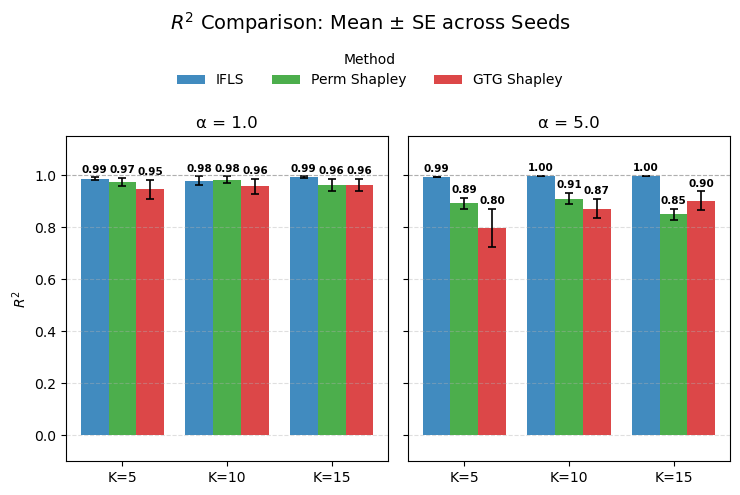

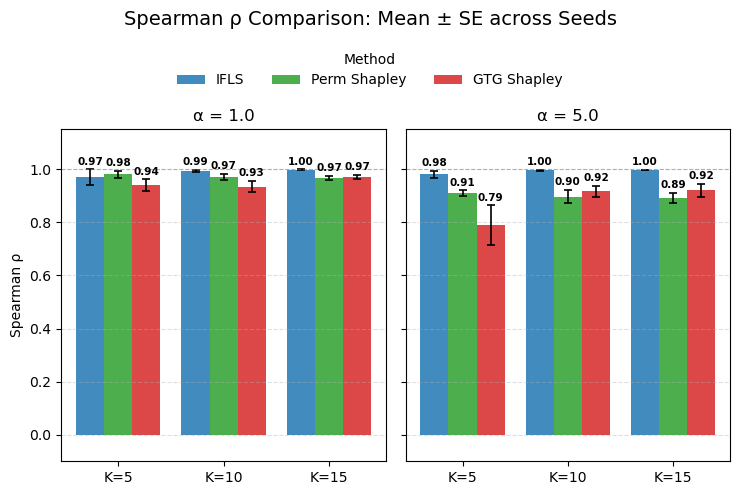

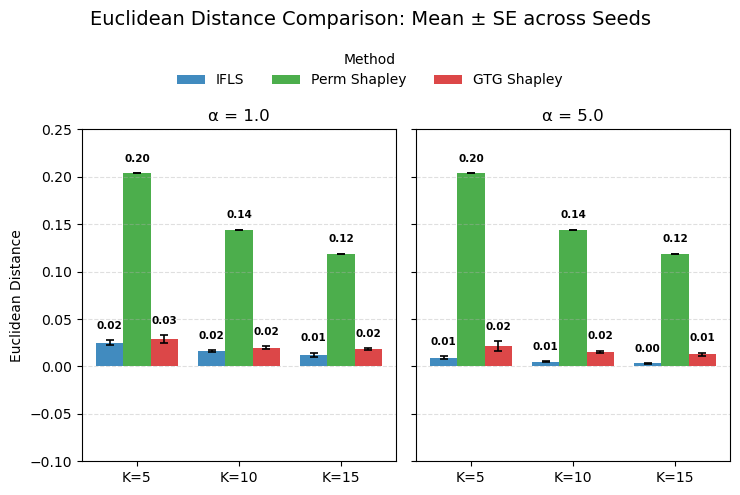

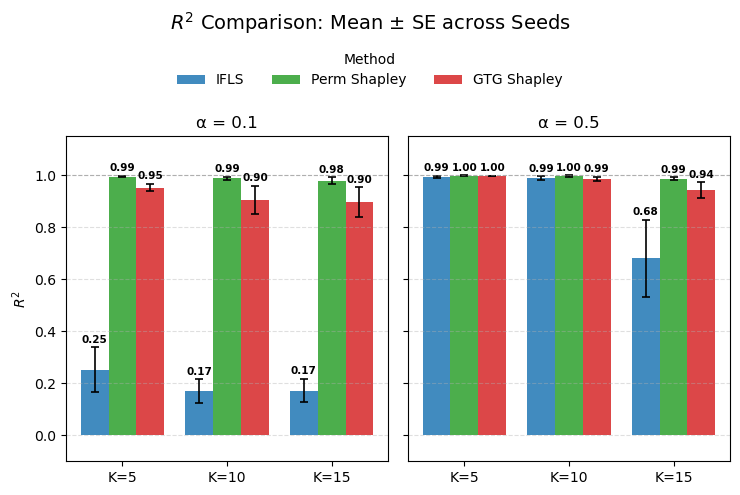

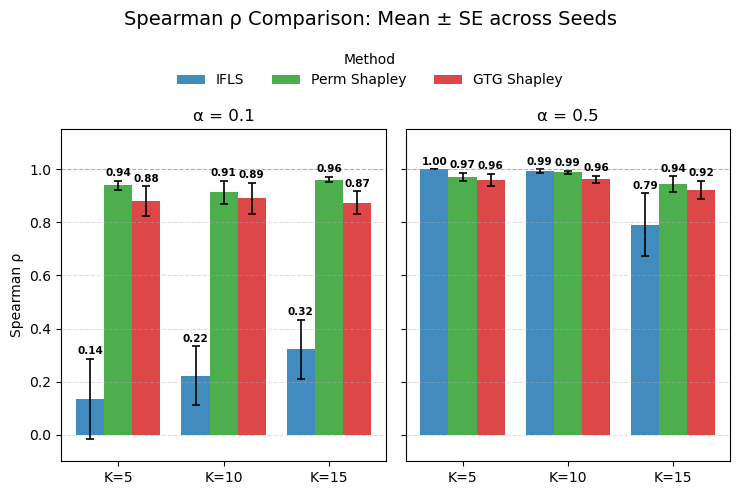

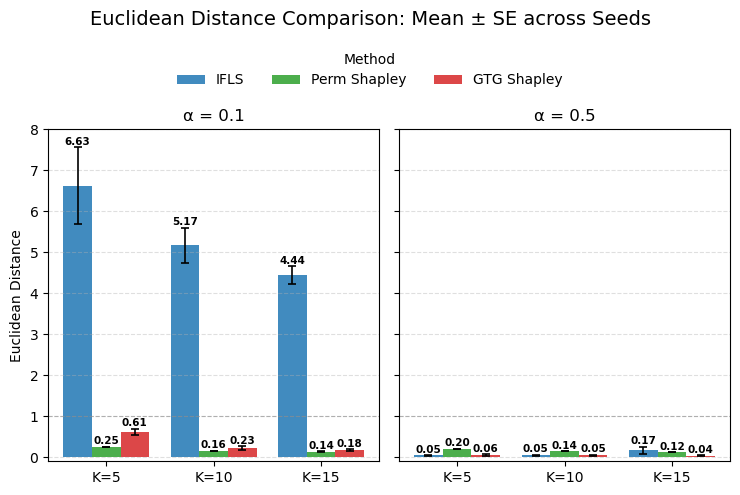

In [12]:
# Classification R²
plot_grouped_bars(
    classification_df, metric='r2',
    title='$R^2$ Comparison: Mean ± SE across Seeds',
    ylabel='$R^2$',
    show_labels= True,
    alpha_values = [1,5]
)

# Classification Spearman
plot_grouped_bars(
    classification_df, metric='spearman',
    title='Spearman ρ Comparison: Mean ± SE across Seeds',
    ylabel='Spearman ρ',
    show_labels= True,
    alpha_values = [1,5]
)

# Classification Euclidean
plot_grouped_bars(
    classification_df, metric='euclidean',
    title='Euclidean Distance Comparison: Mean ± SE across Seeds',
    ylabel='Euclidean Distance',
    ylim=(-0.1, 0.25),  # Euclidean isn't bounded at 1
    show_labels = True,
    alpha_values = [1,5]
)

plot_grouped_bars(
    classification_df, metric='r2',
    title='$R^2$ Comparison: Mean ± SE across Seeds',
    ylabel='$R^2$',
    show_labels= True,
    alpha_values = [0.1,0.5]
)

# Classification Spearman
plot_grouped_bars(
    classification_df, metric='spearman',
    title='Spearman ρ Comparison: Mean ± SE across Seeds',
    ylabel='Spearman ρ',
    show_labels= True,
    alpha_values = [0.1,0.5]
)

# Classification Euclidean
plot_grouped_bars(
    classification_df, metric='euclidean',
    title='Euclidean Distance Comparison: Mean ± SE across Seeds',
    ylabel='Euclidean Distance',
    ylim=(-0.1, 8),  # Euclidean isn't bounded at 1
    show_labels = True,
    alpha_values = [0.1,0.5]
)


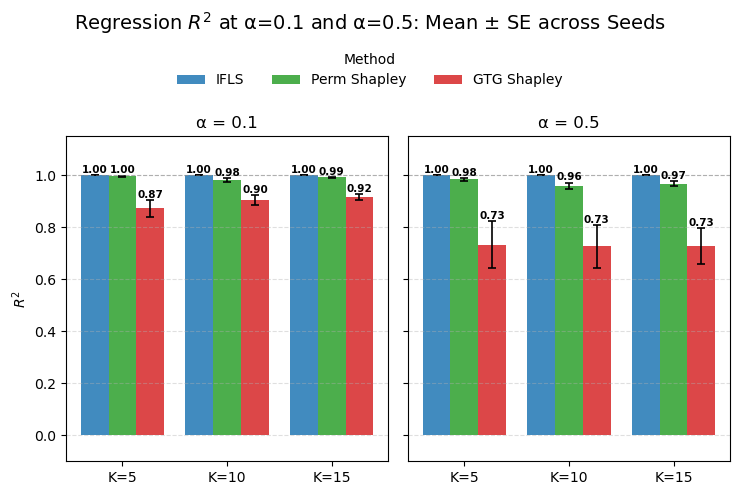

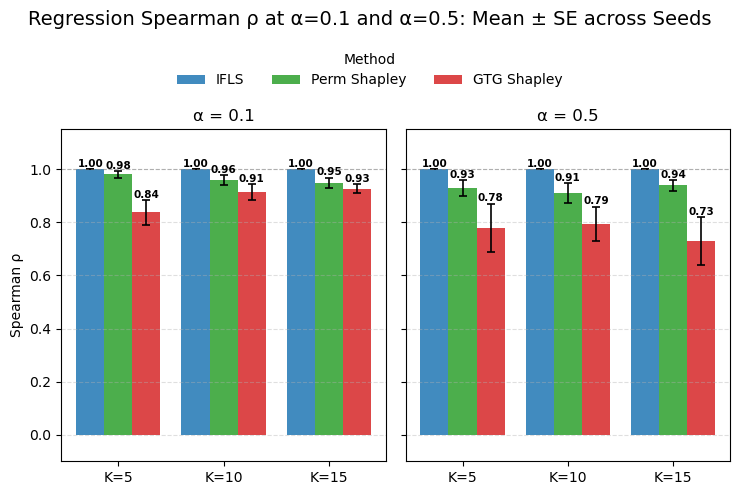

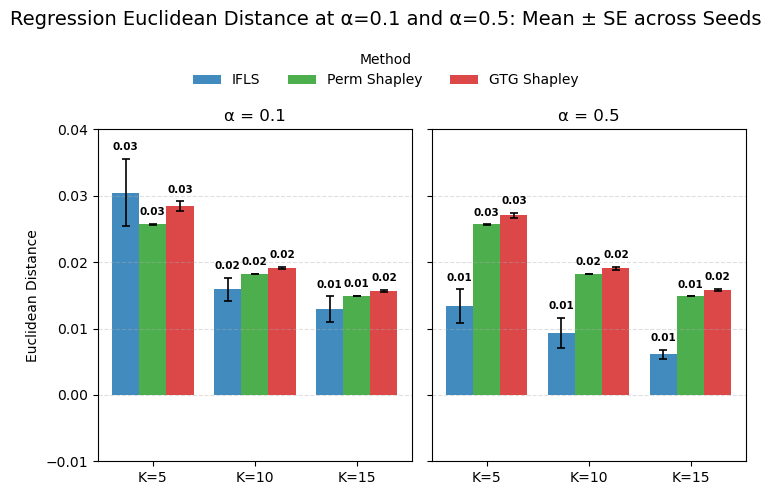

In [22]:
# Regression Plots
# R²
plot_grouped_bars(
    regression_df, metric='r2',
    title='Regression $R^2$ at α=0.1 and α=0.5: Mean ± SE across Seeds',
    ylabel='$R^2$',
    show_labels = True,
    alpha_values = [0.1,0.5]
)

# Spearman
plot_grouped_bars(
    regression_df, metric='spearman',
    title='Regression Spearman ρ at α=0.1 and α=0.5: Mean ± SE across Seeds',
    ylabel='Spearman ρ',
    show_labels = True,
    alpha_values = [0.1,0.5]
)

# Euclidean
plot_grouped_bars(
    regression_df, metric='euclidean',
    title='Regression Euclidean Distance at α=0.1 and α=0.5: Mean ± SE across Seeds',
    ylabel='Euclidean Distance',
    ylim=(-0.01, 0.04),
    show_labels = True,
    alpha_values = [0.1,0.5]
)

In [14]:
### Scenario 2 Results
df_scenario_2 = pd.read_csv('scenario2_results.csv')
print(df_scenario_2.groupby('task')[['ifls_spearman', 'gtg_spearman', 'perm_spearman', 'ifls_r2','gtg_r2','perm_r2']].mean())

                ifls_spearman  gtg_spearman  perm_spearman   ifls_r2  \
task                                                                   
classification       0.156364      0.689697       0.911515  0.132529   
regression           0.110303      0.953939       0.991515  0.101351   

                  gtg_r2   perm_r2  
task                                
classification  0.475666  0.878134  
regression      0.914869  0.995893  


In [36]:
print(df_scenario_2.columns)


Index(['K', 'alpha', 'seed', 'scenario', 'time_exact', 'time_flls',
       'flls_spearman', 'flls_pearson', 'flls_r2', 'flls_cosine',
       'flls_euclidean', 'flls_max_diff', 'time_gtg', 'gtg_spearman',
       'gtg_pearson', 'gtg_r2', 'gtg_cosine', 'gtg_euclidean', 'gtg_max_diff',
       'time_perm', 'perm_spearman', 'perm_pearson', 'perm_r2', 'perm_cosine',
       'perm_euclidean', 'perm_max_diff', 'task'],
      dtype='object')


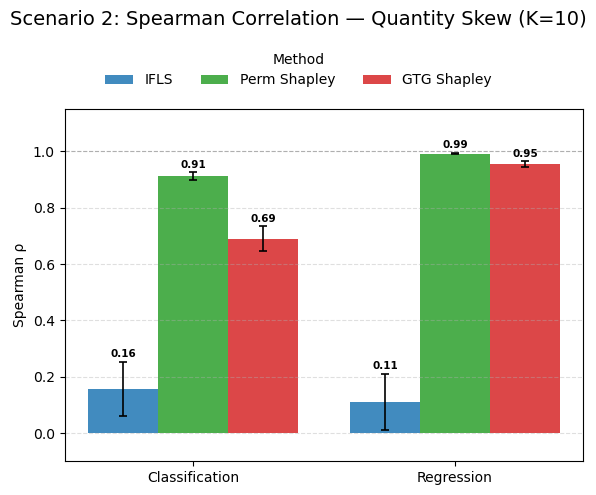

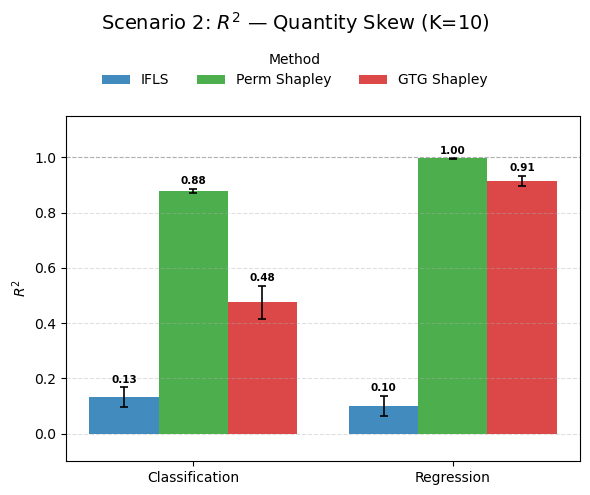

In [15]:
plot_grouped_bars(
    df_scenario_2,
    metric='spearman',
    title='Scenario 2: Spearman Correlation — Quantity Skew (K=10)',
    ylabel='Spearman ρ',
    ylim=(-0.1, 1.15),
    show_labels = True,
    scenario=2
)

plot_grouped_bars(
    df_scenario_2,
    metric='r2',
    title='Scenario 2: $R^2$ — Quantity Skew (K=10)',
    ylabel='$R^2$',
    ylim=(-0.1, 1.15),
    show_labels= True,
    scenario=2
)
